In [3]:
import re 
import time
import sqlite3
import numpy as np
import pandas as pd
import scrape_functions 
from nba_api.stats.endpoints import draftcombinestats
from nba_api.stats.endpoints import playercareerbycollege

In [55]:
url = 'https://www.basketball-reference.com/draft/NBA_2025.html'

soup = scrape_functions.get_soup(url=url)


<!DOCTYPE html>

<html class="no-js" data-root="/home/bbr/build" data-version="klecko-" lang="en">
<head>
<meta charset="utf-8"/>
<meta content="ie=edge" http-equiv="x-ua-compatible"/>
<meta content="width=device-width, initial-scale=1.0, maximum-scale=2.0" name="viewport">
<link href="https://cdn.ssref.net/req/202606251" rel="dns-prefetch"/>
<script>
/* https://docs.osano.com/hc/en-us/articles/22469433444372-Google-Consent-Mode-v2  */
  window.dataLayer = window.dataLayer ||[];
      function gtag(){dataLayer.push(arguments);}
      gtag('consent','default',{
        'ad_storage':'denied',
        'analytics_storage':'denied',
        'ad_user_data':'denied',
        'ad_personalization':'denied',
        'personalization_storage':'denied',
        'functionality_storage':'granted',
        'security_storage':'granted',
        'wait_for_update': 500
      });
      gtag("set", "ads_data_redaction", true);
</script>
<script src="https://cmp.osano.com/16CGnCU8UtNhM14sg/12669873-8cf8-4
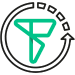
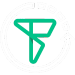

In [ ]:
tbodies = soup.find_all("tbody")

In [53]:
player_info = {
    "Jalen Brunson":      [2018, "Villanova", "brunsja01"],
    "Chris Paul":         [2005, "Wake Forest", "paulch01"],
    "Fred VanVleet":      [2016, "Wichita State", "vanvlfr01"],
    "Kyle Lowry":         [2006, "Villanova", "lowryky01"],
    "Jrue Holiday":       [2009, "UCLA", "holidjr01"],
    "Mike Conley":        [2007, "Ohio State", "conlemi01"],
    "Davion Mitchell":    [2021, "Baylor", "mitchda01"],
    "Tyus Jones":         [2015, "Duke", "jonesty01"],
    "Jalen Suggs":        [2021, "Gonzaga", "suggsja01"],
    "Jamal Murray":       [2016, "Kentucky", "murraja01"],
    "Darius Garland":     [2019, "Vanderbilt", "garlada01"],
    "Mike Bibby":         [1998, "Arizona", "bibbymi01"],
    "Chauncey Billups":   [1997, "Colorado", "billuch01"],
    "Derek Fisher":       [1996, "Arkansas-Little Rock", "fishede01"],
    "Jalen Pickett":      [2023, "Penn State", "pickeja01"],
    "Darius Acuff Jr.":   [2026, "Arkansas", "acuffda01"], 
}

# for player, info in player_info.items():
#     print(f"Getting Player Info: {player}")

#     try:
#         scrape_functions.get_player_data(info[2])
#         time.sleep(np.random.randint(5, 15))

#         # scrape_functions.get_seasonal_stats(info[2])
#         # time.sleep(np.random.randint(5, 15))

#         print('Success')
#     except:
#         print(f'Player Failed: {player}')
#         continue


In [50]:
ids = [item[2] for item in player_info.values()]
years = [item[0] for item in player_info.values()]


with sqlite3.connect('nba.db') as conn:
    data = pd.read_sql_query(
        'SELECT * FROM "per_game_stats"',
        conn
    )

data = data.drop(columns=['awards'])
data = data[data['player'].isin(ids)] # take only players similar to daj

data['year_id'] = data['year_id'].str.slice(0, 4).astype(int) # convert year to integers

# keep only rookie years
data = data.sort_values(['player', 'year_id'])
data = data.drop_duplicates(subset=['player'], keep='first').reset_index(drop=True)


In [51]:
data

,year_id,age,team_name_abbr,comp_name_abbr,pos,games,games_started,mp_per_g,fg_per_g,fga_per_g,...,orb_per_g,drb_per_g,trb_per_g,ast_per_g,stl_per_g,blk_per_g,tov_per_g,pf_per_g,pts_per_g,player
0,1998,20,VAN,NBA,PG,50,50,35.2,5.2,12.1,...,0.6,2.1,2.7,6.5,1.6,0.1,2.9,2.4,13.2,bibbymi01
1,1997,21,2TM,NBA,PG,80,70,27.7,3.5,9.4,...,0.8,1.6,2.4,3.9,1.3,0.1,2.2,2.2,11.2,billuch01
2,2018,22,DAL,NBA,PG,73,38,21.8,3.6,7.7,...,0.3,2.0,2.3,3.2,0.5,0.1,1.2,1.7,9.3,brunsja01
3,2007,20,MEM,NBA,PG,53,46,26.1,3.6,8.3,...,0.4,2.2,2.6,4.2,0.8,0.0,1.7,1.6,9.4,conlemi01
4,1996,22,LAL,NBA,PG,80,3,11.5,1.3,3.3,...,0.3,0.9,1.2,1.5,0.5,0.1,0.9,1.1,3.9,fishede01
5,2019,20,CLE,NBA,SG,59,59,30.9,4.7,11.8,...,0.5,1.4,1.9,3.9,0.7,0.1,2.6,1.6,12.3,garlada01
6,2009,19,PHI,NBA,PG,73,51,24.2,3.2,7.1,...,0.8,1.8,2.6,3.8,1.1,0.2,2.1,2.1,8.0,holidjr01
7,2015,19,MIN,NBA,PG,37,0,15.5,1.5,4.2,...,0.2,1.1,1.3,2.9,0.8,0.1,0.9,0.9,4.2,jonesty01
8,2006,20,MEM,NBA,PG,10,0,17.5,1.4,3.8,...,1.2,1.9,3.1,3.2,1.4,0.1,1.2,2.0,5.6,lowryky01
9,2021,23,SAC,NBA,PG,75,19,27.7,4.7,11.2,...,0.4,1.8,2.2,4.2,0.7,0.3,1.5,1.9,11.5,mitchda01
